# Exploratory Data Analysis (EDA) - Fraud Detection
Notebook ini berisi analisis data eksploratif (EDA) untuk dataset deteksi akun palsu (fraud detection).
Fokus utama adalah membedakan pola antara akun normal dan akun palsu (fake accounts).

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

In [26]:
# Load Analytical Base Table (ABT)
abt_df = pd.read_csv('../data/abt/fake_account_abt.csv')

# Load Transactions for time series
tx_df = pd.read_csv('../data/raw/transactions.csv')
tx_df['transaction_date'] = pd.to_datetime(tx_df['transaction_date'])

print(f"ABT Shape: {abt_df.shape}")
print(f"Transactions Shape: {tx_df.shape}")

ABT Shape: (10000, 61)
Transactions Shape: (52256, 13)


---
### 1 & 2. Total Users dan Transactions
Menghitung jumlah keseluruhan populasi user dan transaksi dari dataset yang ada.

In [27]:
# 1. Total Users
total_users = abt_df['uid'].nunique()
print(f"Total Users: {total_users:,}")

# 2. Total Transactions
total_tx = tx_df['transaction_id'].nunique()
print(f"Total Transactions: {total_tx:,}")

Total Users: 10,000
Total Transactions: 52,256


**Insight:** Dataset mensimulasikan platform retail mobile berskala menengah. Proporsi pengguna dan transaksi ini menjadi dasar analisis rasio aktivitas per pengguna.

---
### 3 & 4. Distribusi Kelas Target & Tipe Fraud
Melihat seberapa tidak seimbang (imbalanced) rasio akun asli vs palsu, dan jenis-jenis kecurangan yang paling mendominasi.

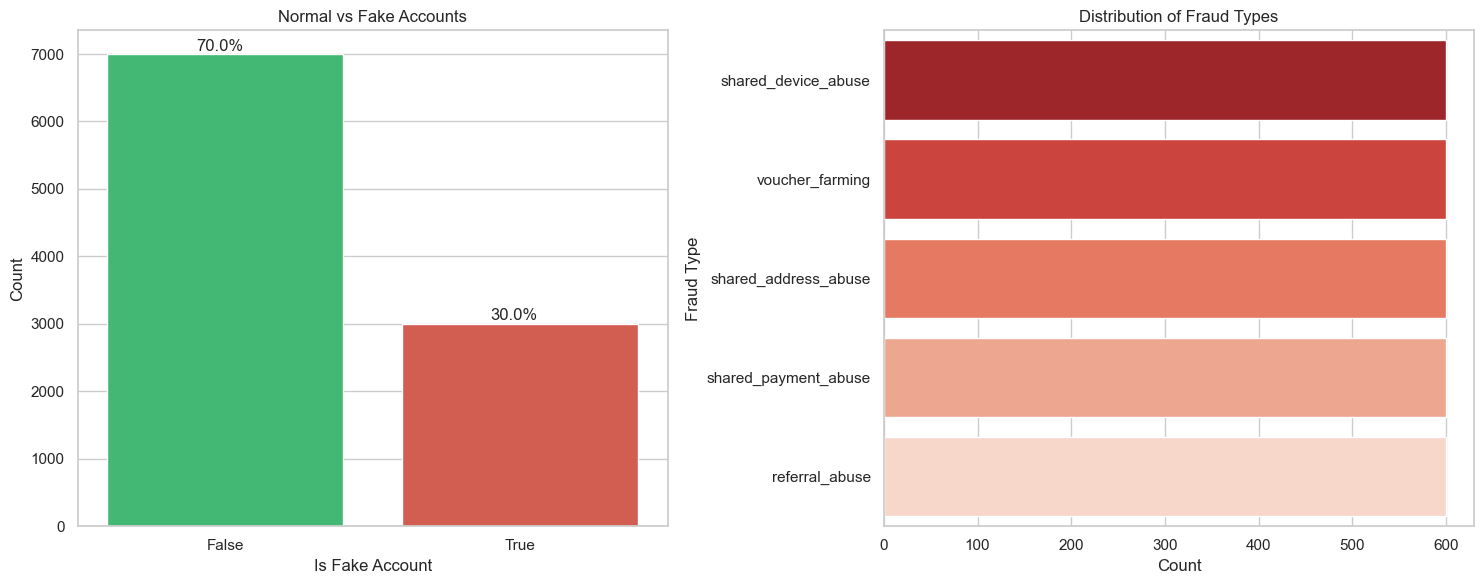

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 3. Fake vs Normal Distribution (Bar Chart)
sns.countplot(data=abt_df, x='fraud', ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Normal vs Fake Accounts')
axes[0].set_xlabel('Is Fake Account')
axes[0].set_ylabel('Count')

# Add percentages
total = len(abt_df)
for p in axes[0].patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_y() + p.get_height() + 50
    axes[0].annotate(percentage, (x, y))

# 4. Fraud Type Distribution (Bar Chart)
fraud_df = abt_df[abt_df['fraud'] == True]
sns.countplot(data=fraud_df, y='ftype', ax=axes[1], palette='Reds_r',
              order=fraud_df['ftype'].value_counts().index)
axes[1].set_title('Distribution of Fraud Types')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Fraud Type')

plt.tight_layout()
plt.show()


**Insight:**
- Dataset memiliki rasio ~70% Normal dan ~30% Fake — cukup realistis untuk simulasi fraud detection.
- Fraud terbesar didominasi oleh `voucher_farming`, diikuti skenario penyalahgunaan device/emulator. Ini membuktikan motivasi utama akun palsu adalah insentif finansial (promo/voucher/referral).

---
### 5. Distribusi Waktu Pendaftaran Hingga Transaksi Pertama
Akun palsu biasanya dibuat secara massal dan langsung digunakan secepat kilat untuk mengklaim promo. Grafik `reg2txn_min` ini membuktikan asumsi tersebut.

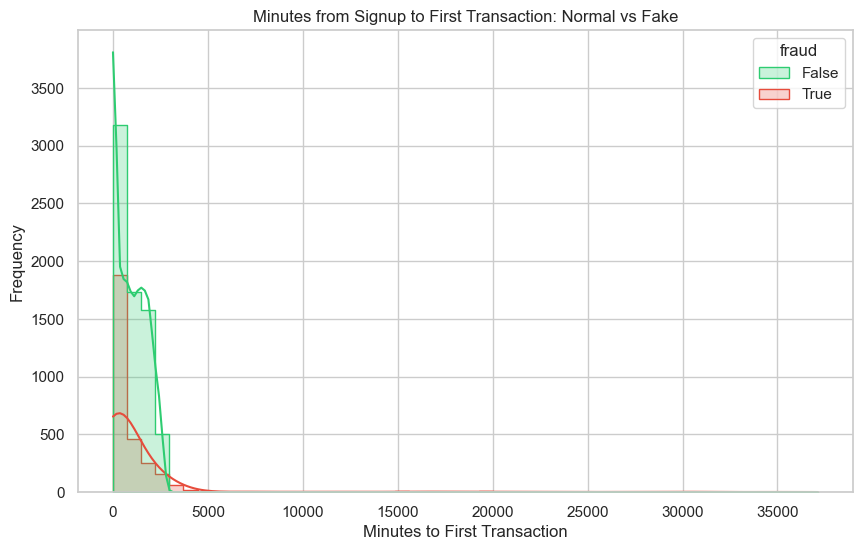

In [29]:
# 5. Registration to First Transaction (Histogram)
# Menggantikan account_age_days yang sudah dihapus dari ABT
plt.figure(figsize=(10, 6))
sns.histplot(data=abt_df, x='reg2txn_min', hue='fraud',
             bins=50, kde=True, palette=['#2ecc71', '#e74c3c'], element='step')
plt.title('Minutes from Signup to First Transaction: Normal vs Fake')
plt.xlabel('Minutes to First Transaction')
plt.ylabel('Frequency')
plt.show()


**Insight:** Sebagian besar akun palsu (merah) terkonsentrasi di waktu yang sangat singkat (0–30 menit setelah mendaftar), sedangkan akun normal terdistribusi lebih merata dan butuh waktu lebih lama untuk melakukan transaksi. Pola ini dikenal sebagai **"Hit and Run" behavior**.

---
### 6. Distribusi Penggunaan Promo
Menganalisis seberapa sering akun mengeksploitasi promo — dihitung sebagai rasio transaksi berpromo terhadap total transaksi.

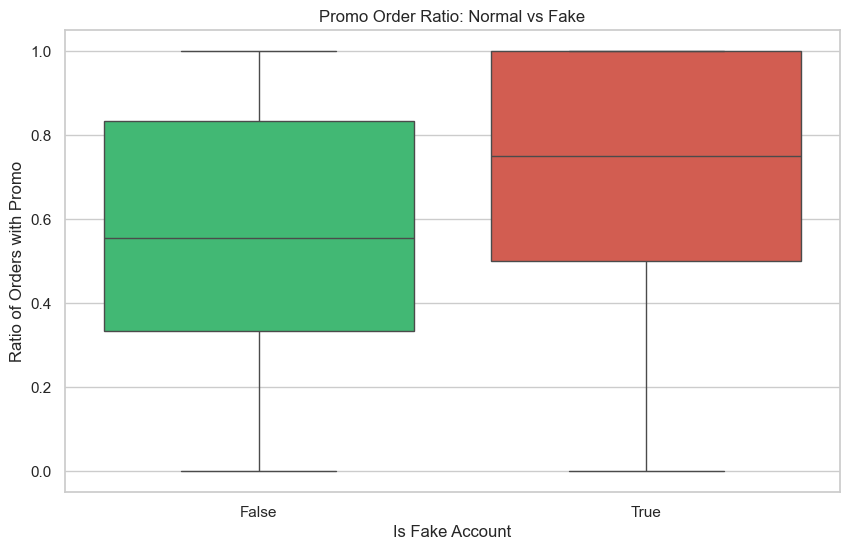

In [30]:
# 6. Promo Usage Distribution (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=abt_df, x='fraud', y='promo_ratio',
            palette=['#2ecc71', '#e74c3c'])
plt.title('Promo Order Ratio: Normal vs Fake')
plt.xlabel('Is Fake Account')
plt.ylabel('Ratio of Orders with Promo')
plt.show()

**Insight:** Akun palsu memiliki rasio promo mendekati 1.0 (hampir 100% transaksinya menggunakan voucher/promo). Akun normal memiliki rasio lebih bervariasi. Ini adalah sinyal kuat untuk deteksi `voucher_farming`.

---
### 7, 8, 9. Shared Entities: Device, Address, Payment
Mendeteksi anomali di mana banyak akun berbagi properti yang sama — perangkat, alamat pengiriman, atau metode pembayaran.

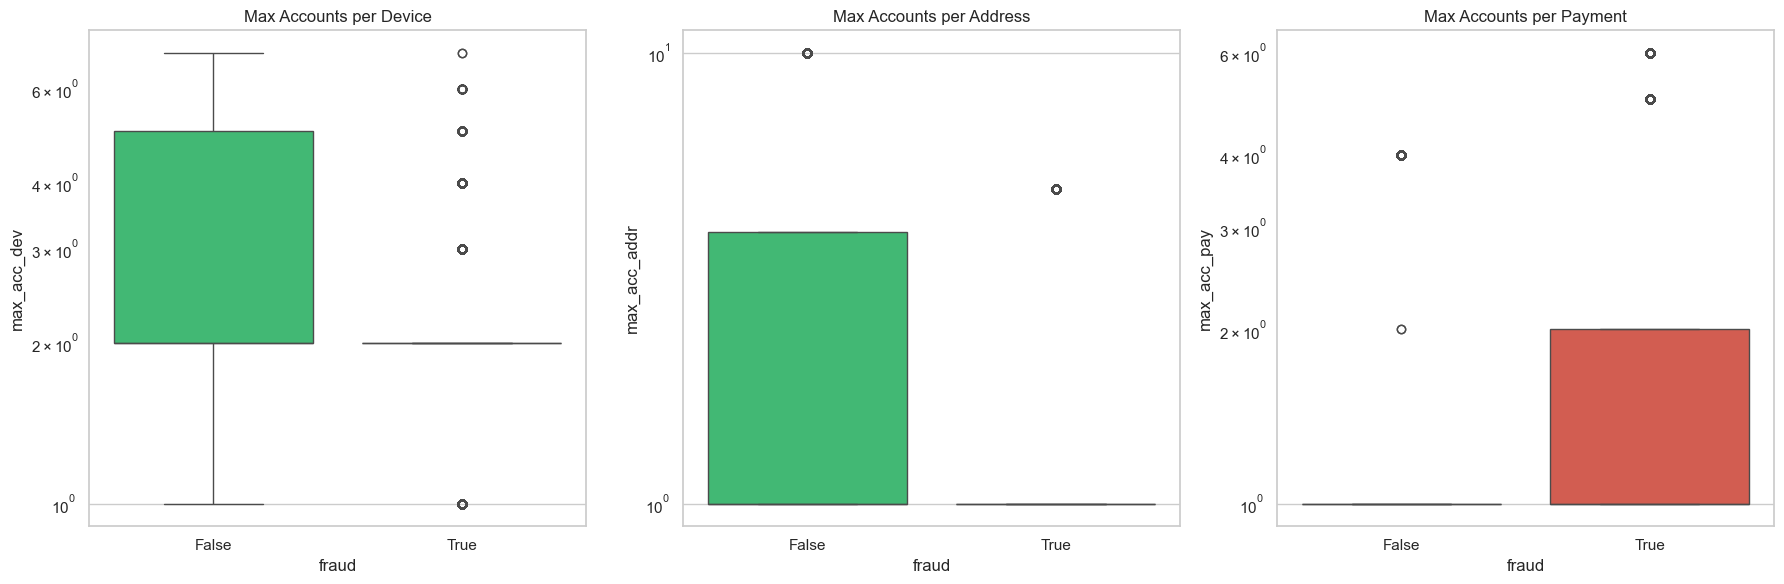

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 7. Accounts per Device
sns.boxplot(data=abt_df, x='fraud', y='max_acc_dev',
            ax=axes[0], palette=['#2ecc71', '#e74c3c'])
axes[0].set_title('Max Accounts per Device')
axes[0].set_yscale('log')

# 8. Accounts per Address
sns.boxplot(data=abt_df, x='fraud', y='max_acc_addr',
            ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Max Accounts per Address')
axes[1].set_yscale('log')

# 9. Accounts per Payment
sns.boxplot(data=abt_df, x='fraud', y='max_acc_pay',
            ax=axes[2], palette=['#2ecc71', '#e74c3c'])
axes[2].set_title('Max Accounts per Payment')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()


**Insight:** Ditampilkan dalam skala logaritmik karena perbedaannya sangat ekstrem. Akun palsu bisa berbagi satu device/alamat/payment dengan puluhan akun lain (fraud ring), sedangkan akun normal hanya 1–3 akun per entitas.

> **Catatan:** Ada tumpang tindih nilai antara akun normal dan palsu, karena data sengaja diberi *noise* — misalnya 20% akun normal memang berbagi alamat (keluarga/kantor). Ini membuat deteksi dengan aturan satu fitur saja tidak cukup andal.

---
### 10. Volume Transaksi Bulanan
Time series untuk melihat tren aktivitas transaksi aplikasi retail dari waktu ke waktu.

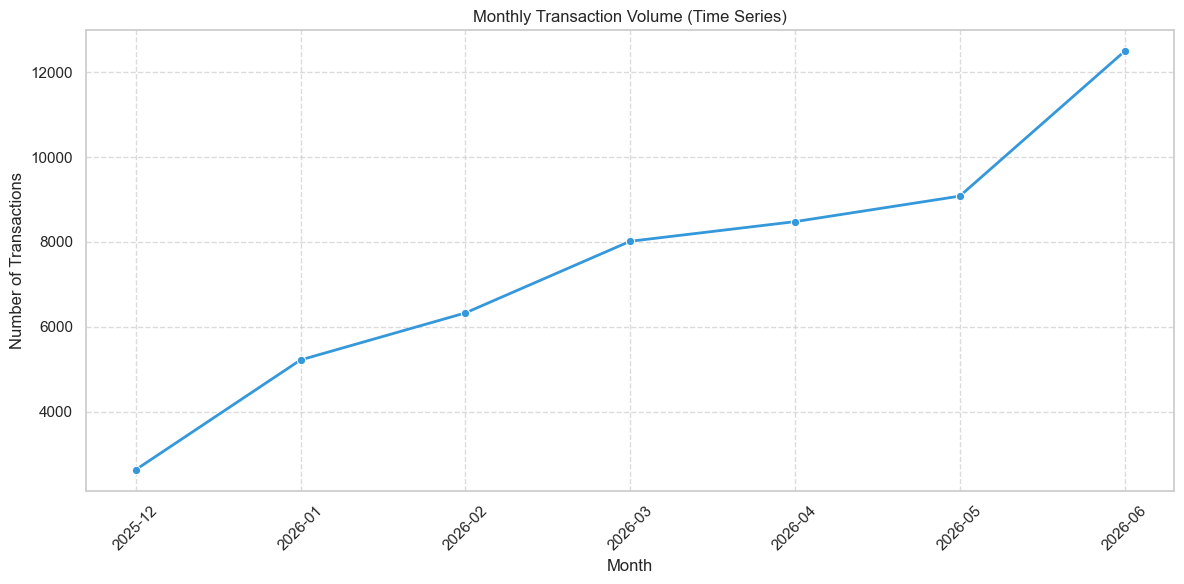

In [32]:
# 10. Transactions by Month (Time Series)
tx_df['month_year'] = tx_df['transaction_date'].dt.to_period('M')
monthly_tx = tx_df.groupby('month_year').size().reset_index(name='transaction_count')
monthly_tx['month_year'] = monthly_tx['month_year'].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_tx, x='month_year', y='transaction_count',
             marker='o', color='#3498db', linewidth=2)
plt.title('Monthly Transaction Volume (Time Series)')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Insight:** Tren volume transaksi bulanan memperlihatkan apakah ada lonjakan (spike) di bulan tertentu. Lonjakan tidak wajar biasanya berkorelasi dengan event promo besar yang diserang fraudster secara terkoordinasi.

---
### 11, 12, 13. Top Entitas Mencurigakan
Menampilkan akun dengan nilai *sharing* paling tinggi pada masing-masing entitas.

In [33]:
print("=== Top Suspicious Entities ===")

# 11. Top suspicious devices
print("\nTop Suspicious Devices (by max accounts associated):")
top_devices = (abt_df[['uid', 'max_acc_dev', 'fraud']]
               .sort_values('max_acc_dev', ascending=False).head(5))
print(top_devices.to_string(index=False))

# 12. Top suspicious addresses
print("\nTop Suspicious Addresses (by max accounts associated):")
top_addresses = (abt_df[['uid', 'max_acc_addr', 'fraud']]
                 .sort_values('max_acc_addr', ascending=False).head(5))
print(top_addresses.to_string(index=False))

# 13. Top suspicious payments
print("\nTop Suspicious Payments (by max accounts associated):")
top_payments = (abt_df[['uid', 'max_acc_pay', 'fraud']]
                .sort_values('max_acc_pay', ascending=False).head(5))
print(top_payments.to_string(index=False))


=== Top Suspicious Entities ===

Top Suspicious Devices (by max accounts associated):
     uid  max_acc_dev  fraud
USR07268            7   True
USR07571            7  False
USR02068            7  False
USR02067            7  False
USR02065            7  False

Top Suspicious Addresses (by max accounts associated):
     uid  max_acc_addr  fraud
USR00001            10  False
USR01369            10  False
USR01501            10  False
USR01500            10  False
USR01495            10  False

Top Suspicious Payments (by max accounts associated):
     uid  max_acc_pay  fraud
USR07426            6   True
USR07459            6   True
USR09198            6   True
USR04100            6   True
USR07889            6   True


**Insight:** Hasil printout menunjukkan bahwa entitas dengan jumlah akun terbanyak **belum tentu semuanya akun palsu**.

- **Top Devices:** Campuran antara akun normal dan fake — bisa jadi warnet, toko, atau HP keluarga.
- **Top Addresses:** Mayoritas akun normal — mencerminkan alamat apartemen atau kantor yang wajar dipakai banyak orang.
- **Top Payments:** Campuran — bisa berupa kartu kredit bersama atau e-wallet keluarga.

> **Kesimpulan penting:** Pendekatan berbasis aturan tunggal (misal: blokir jika >5 akun per device) akan menghasilkan banyak **false positive** — memblokir pengguna yang sah. Inilah mengapa dibutuhkan **model Machine Learning** yang menggabungkan seluruh fitur secara bersamaan untuk menghasilkan keputusan yang lebih akurat.

---
### 14. Correlation Heatmap
Menentukan fitur mana yang paling berkorelasi dengan label `fraud`. Informasi ini krusial dalam pemilihan dan pemahaman fitur untuk model Machine Learning.

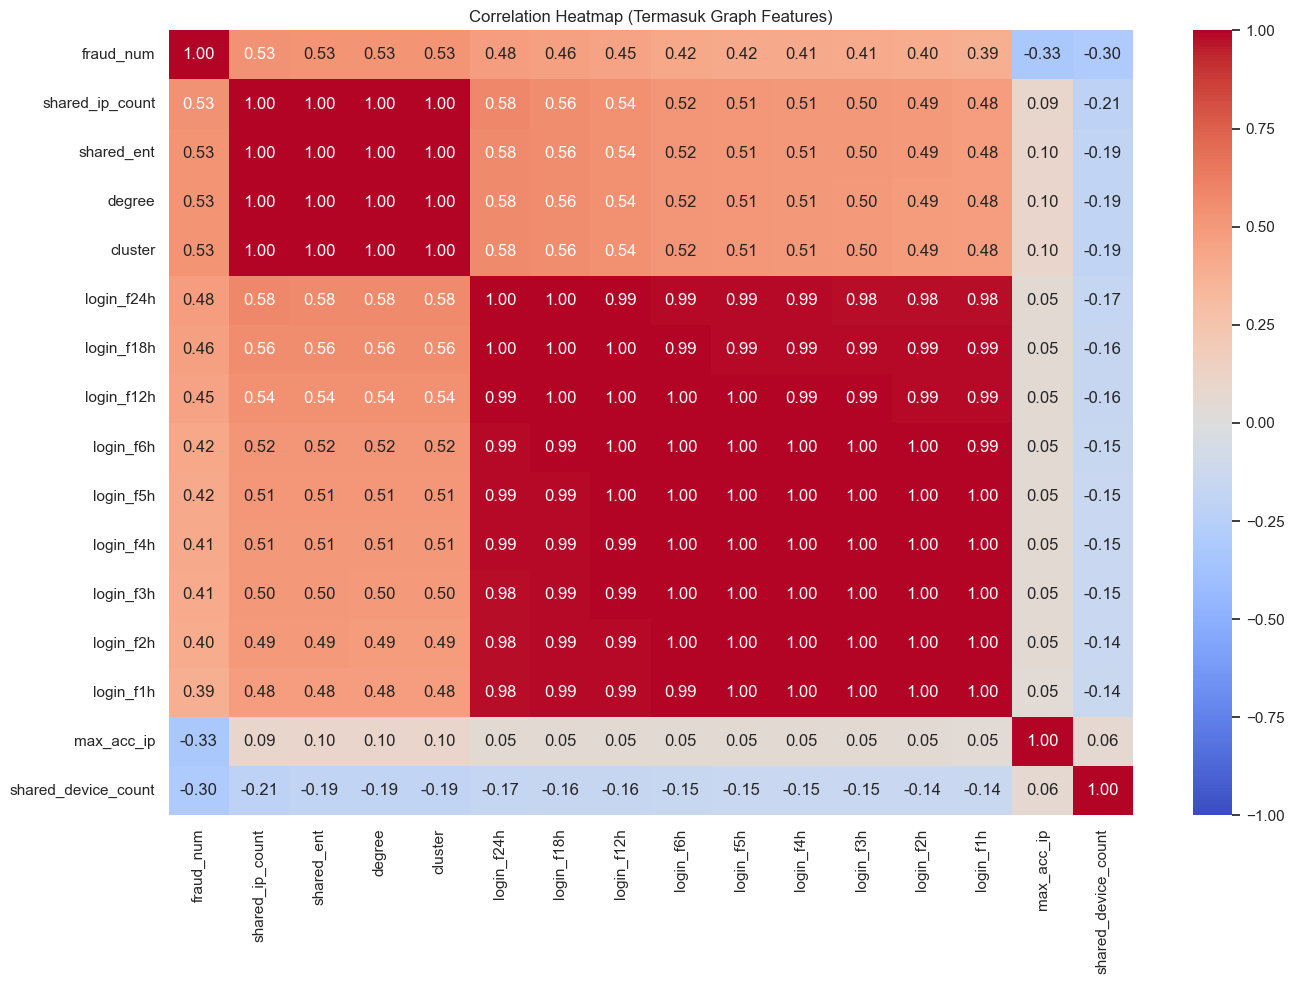

In [41]:
# 14. Correlation Heatmap
import numpy as np

# 1. Gabungkan dengan graph features agar masuk ke Heatmap
df_graph = pd.read_csv('../data/processed/user_graph_features.csv')
df_graph = df_graph.rename(columns={
    'user_id': 'uid',
    'graph_degree': 'degree',
    'graph_cluster_size': 'cluster',
    'connected_component_size': 'comp_size',
    'shared_entity_count': 'shared_ent'
})

abt_df = abt_df.merge(df_graph, on='uid', how='left').fillna(0)

# 2. Persiapkan Heatmap
numeric_cols = abt_df.select_dtypes(include=[np.number]).columns.tolist()

if 'fraud' in abt_df.columns:
    abt_df['fraud_num'] = abt_df['fraud'].astype(int)
    if 'fraud_num' not in numeric_cols:
        numeric_cols.append('fraud_num')

corr_matrix = abt_df[numeric_cols].corr()
top_features = corr_matrix['fraud_num'].abs().sort_values(ascending=False).index[:16]

plt.figure(figsize=(14, 10))
sns.heatmap(abt_df[top_features].corr(), annot=True, cmap='coolwarm',
            fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap (Termasuk Graph Features)')
plt.tight_layout()
plt.show()


**Insight Akhir:**
- Fitur dengan korelasi tertinggi terhadap label fraud kini didominasi oleh metrik *velocity* (seperti **`login_f24h`** yang mendeteksi spam login) dan *graph analysis* (seperti **`shared_ip_count`**).
- Kemunculan fitur jaringan di puncak korelasi membuktikan bahwa **analisis koneksi antar-akun sangat penting** dalam menemukan komplotan penipu (*fraud rings*) yang merekayasa IP dan perangkat.
- Tidak ada satu fitur tunggal yang sempurna. Model ML (XGBoost) perlu menggabungkan seluruh fitur ini secara bersamaan untuk mencapai akurasi >90%.